Importing required packages for required execution

In [1]:
import os
from google.colab import drive
import scipy.io
import numpy as np
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from keras.applications import  MobileNet
from tensorflow import keras
from keras import models, layers
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [2]:
 drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
image_path = '/content/gdrive/MyDrive/flowers/'

Listing the images in flowers folder and capturing the name of the files in images variable





In [4]:
files = os.listdir(image_path)
files = [item for item in files if ')' not in item]
images = [item for item in files if 'ipynb_checkpoints' not in item]
print("Total no of images:",len(images))

Total no of images: 8189


Sorting the images so that the images and labels are in order

In [5]:
 images.sort()

In [6]:
 print(f"images: {images[:5]}...")

images: ['image_00001.jpg', 'image_00002.jpg', 'image_00003.jpg', 'image_00004.jpg', 'image_00005.jpg']...


Loading the labels and setid mat files using scipy package

In [7]:
labels = scipy.io.loadmat('/content/gdrive/MyDrive/imagelabels.mat')
splits = scipy.io.loadmat('/content/gdrive/MyDrive/setid.mat')

In [8]:
label = labels['labels']
print("Length of Labels:", label.size)
print('Length of Testing set:', splits['trnid'].size)
print('Length of Training set : ', splits['tstid'].size)
print('Length of validation set:', splits['valid'].size)

Length of Labels: 8189
Length of Testing set: 1020
Length of Training set :  6149
Length of validation set: 1020


In [9]:
label

array([[77, 77, 77, ..., 62, 62, 62]], dtype=uint8)

Creating folders Training, Testing, Validation to seperate the images according to the split id's

In [10]:
sets = ['../content/Training', '../content/Testing', '../content/Validation']

for i in sets:
    os.mkdir(i)
    for j in range(1, 103):
        os.mkdir(i + f'/{j}')

Copying the images into the above created folders based on their split id's

In [11]:
def copy_images(image_ids, images, image_path, destination_folder, label):
    for img_id in image_ids:
        img = images[img_id - 1]
        source = image_path + img
        destination = f"../content/{destination_folder}/{label[0][img_id-1]}"
        shutil.copy(source, destination)

def split_and_copy_images(splits, images, image_path, label):
    print("Start splitting....")

    print("Copying testing data.....")
    copy_images(splits['trnid'][0], images, image_path, "Testing", label)

    print("Copying validation data.....")
    copy_images(splits['valid'][0], images, image_path, "Validation", label)

    print("Copying training data.....")
    copy_images(splits['tstid'][0], images, image_path, "Training", label)

    print("Splitting finished")


split_and_copy_images(splits, images, image_path, label)

Start splitting....
Copying testing data.....
Copying validation data.....
Copying training data.....
Splitting finished


Applying data augmentation to produce variations of image at each epoch, rescaling the image and creating train, test, and valid generators for the images to flow from their respective directories in batches at required size

In [12]:
 train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    '../content/Training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)


valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    '../content/Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)


test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '../content/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)

Found 6149 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.


Using pretrained model MobileNet as the basemodel and adding layer on top of it for experimentation

In [13]:
base_model = MobileNet(include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

var = Flatten()(base_model.output)
var = Dense(256, activation='relu')(var)
var = Dropout(0.4)(var)
predictions = Dense(102, activation='softmax')(var)

17225924/17225924 [==============================] - 0s 0us/step


In [14]:
 model = Model(inputs=base_model.input, outputs=predictions)

 model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

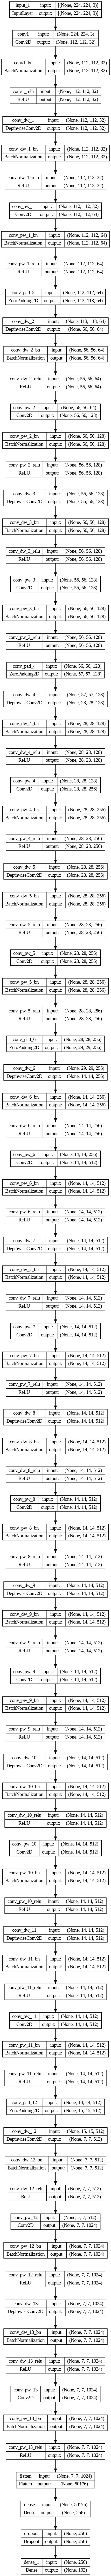

In [48]:
plot_model(model, to_file='model_architecture.png', show_shapes=True)

creating a variable early_stopping so that the training stops when the loss increases to reduce overfitting

In [15]:
early_stoping = EarlyStopping(monitor='val_loss',patience=3,verbose=1)

Training the model with train_generator for 30 epochos by setting the callback and used valid_generator for validation

In [16]:
history=model.fit(train_generator, epochs=30, validation_data=valid_generator,callbacks=[early_stoping])

Epoch 1/30
193/193 [==============================] - 106s 501ms/step - loss: 3.7294 - accuracy: 0.2130 - val_loss: 2.7986 - val_accuracy: 0.3490
Epoch 2/30
193/193 [==============================] - 88s 457ms/step - loss: 2.3634 - accuracy: 0.4503 - val_loss: 1.8612 - val_accuracy: 0.5627
Epoch 3/30
193/193 [==============================] - 93s 480ms/step - loss: 1.7744 - accuracy: 0.5585 - val_loss: 1.3010 - val_accuracy: 0.6941
Epoch 4/30
193/193 [==============================] - 90s 465ms/step - loss: 1.4340 - accuracy: 0.6364 - val_loss: 1.0332 - val_accuracy: 0.7324
Epoch 5/30
193/193 [==============================] - 89s 463ms/step - loss: 1.1951 - accuracy: 0.6871 - val_loss: 0.8388 - val_accuracy: 0.7843
Epoch 6/30
193/193 [==============================] - 90s 465ms/step - loss: 1.0321 - accuracy: 0.7291 - val_loss: 0.7308 - val_accuracy: 0.8147
Epoch 7/30
193/193 [==============================] - 89s 461ms/step - loss: 0.9167 - accuracy: 0.7487 - val_loss: 0.6517 - val_a

Evaluating the model with unseen data from the test_generator

In [17]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

32/32 [==============================] - 4s 120ms/step - loss: 0.5069 - accuracy: 0.8725
Test Loss: 0.5069, Test Accuracy: 0.8725


predicting the labels for the images in valid_generator, comparining it with the true labels and plotting the confusion_matrix

32/32 [==============================] - 8s 198ms/step


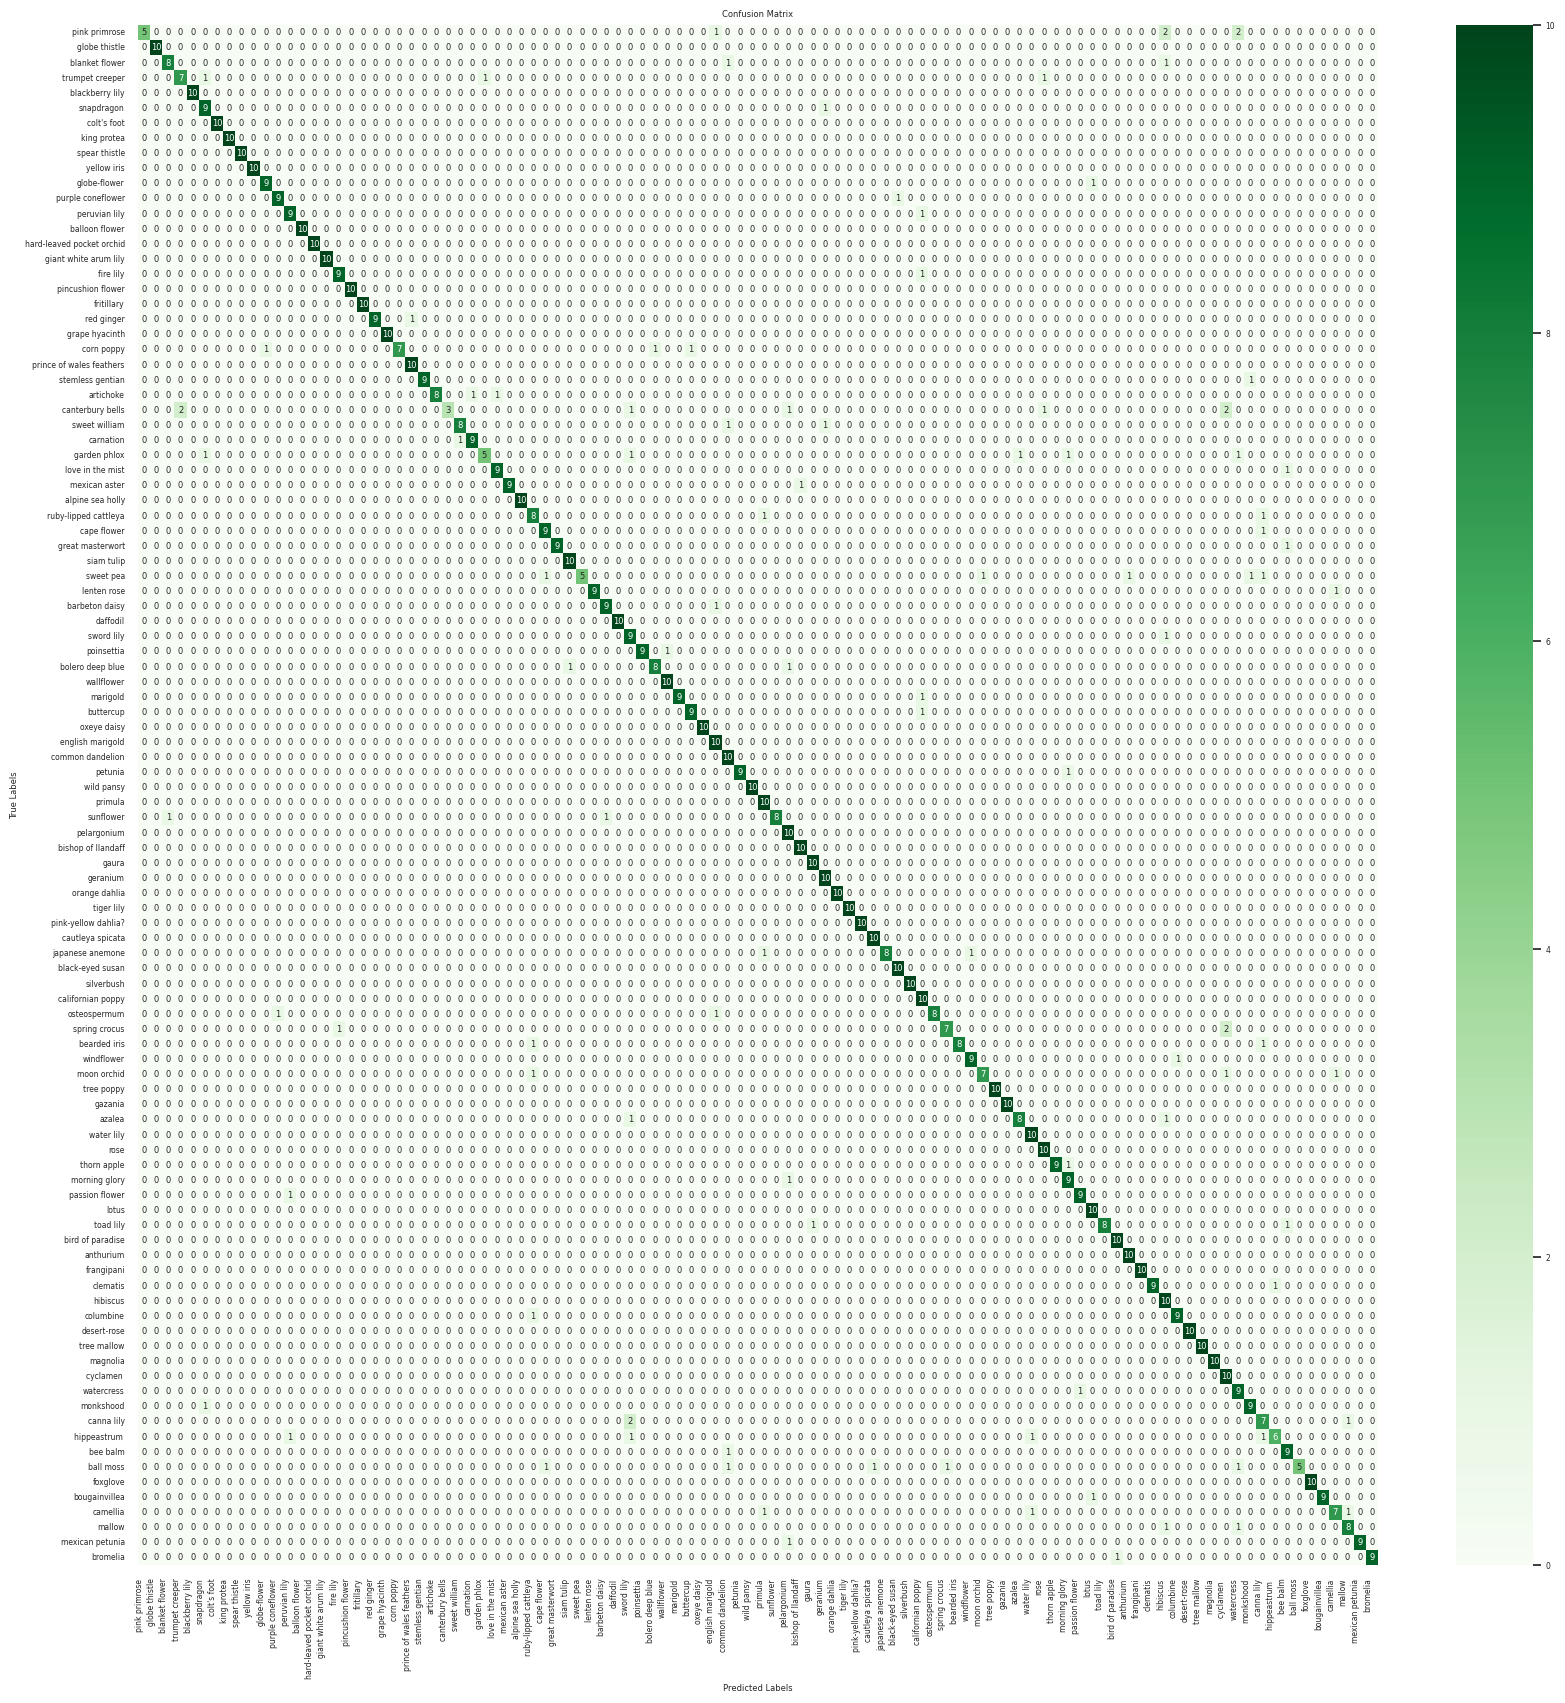

In [47]:
predictions = model.predict(valid_generator)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = valid_generator.classes

def plot_confusion_matrix(confusion_mat, class_names, display_subset=True):
    plt.figure(figsize=(20, 20))
    sns.set(font_scale=0.5)
    sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Greens", xticklabels=class_names,yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90, ha="right")
    plt.yticks(rotation=0)
    plt.show()

confusion_mat = confusion_matrix(true_labels, predicted_labels)

plot_confusion_matrix(confusion_mat, flowers_list)





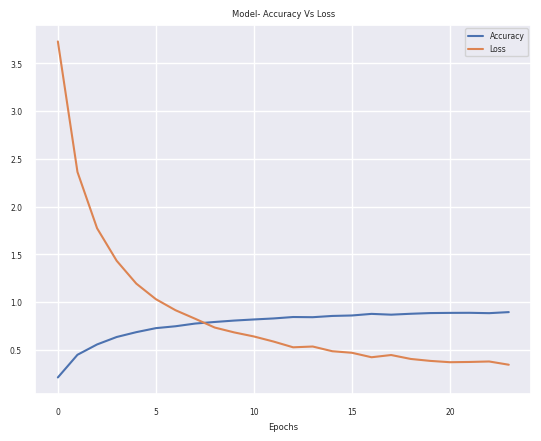

In [29]:
plt.plot(range(len(history.history['accuracy'])),history.history['accuracy'])
plt.plot(range(len(history.history['loss'])),history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

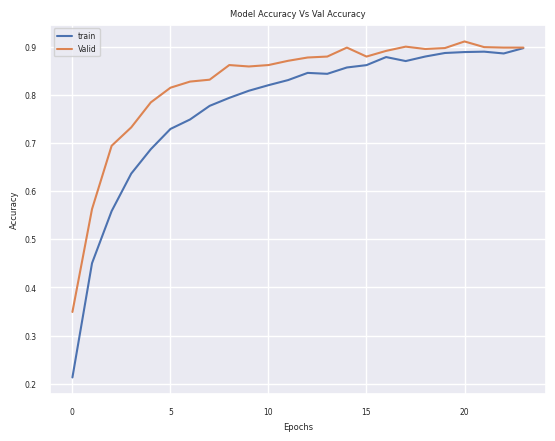

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy Vs Val Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

Below are the names of 102 flowers used for classification


In [19]:
label_names = ['pink primrose','hard-leaved pocket orchid','canterbury bells','sweet pea','english marigold','tiger lily','moon orchid','bird of paradise',
'monkshood','globe thistle','snapdragon',"colt's foot",'king protea','spear thistle','yellow iris','globe-flower',
'purple coneflower','peruvian lily','balloon flower','giant white arum lily','fire lily','pincushion flower','fritillary','red ginger',
'grape hyacinth','corn poppy','prince of wales feathers','stemless gentian','artichoke','sweet william','carnation','garden phlox','love in the mist',
'mexican aster','alpine sea holly','ruby-lipped cattleya','cape flower','great masterwort','siam tulip','lenten rose','barbeton daisy','daffodil',
'sword lily','poinsettia','bolero deep blue','wallflower','marigold','buttercup','oxeye daisy','common dandelion','petunia','wild pansy','primula',
'sunflower','pelargonium','bishop of llandaff','gaura','geranium','orange dahlia','pink-yellow dahlia?','cautleya spicata','japanese anemone',
'black-eyed susan','silverbush','californian poppy','osteospermum','spring crocus','bearded iris','windflower','tree poppy','gazania','azalea',
'water lily','rose','thorn apple','morning glory','passion flower','lotus','toad lily','anthurium','frangipani','clematis','hibiscus','columbine',
'desert-rose','tree mallow','magnolia','cyclamen ','watercress','canna lily','hippeastrum ','bee balm','ball moss','foxglove','bougainvillea',
'camellia','mallow','mexican petunia','bromelia','blanket flower','trumpet creeper','blackberry lily']

Creating a dictionary with key as the position of the flower in the list and value as the name of the flower for mapping in next step

In [20]:
label_dict = {i + 1: label_names[i] for i in range(len(label_names))}
print(label_dict)

{1: 'pink primrose', 2: 'hard-leaved pocket orchid', 3: 'canterbury bells', 4: 'sweet pea', 5: 'english marigold', 6: 'tiger lily', 7: 'moon orchid', 8: 'bird of paradise', 9: 'monkshood', 10: 'globe thistle', 11: 'snapdragon', 12: "colt's foot", 13: 'king protea', 14: 'spear thistle', 15: 'yellow iris', 16: 'globe-flower', 17: 'purple coneflower', 18: 'peruvian lily', 19: 'balloon flower', 20: 'giant white arum lily', 21: 'fire lily', 22: 'pincushion flower', 23: 'fritillary', 24: 'red ginger', 25: 'grape hyacinth', 26: 'corn poppy', 27: 'prince of wales feathers', 28: 'stemless gentian', 29: 'artichoke', 30: 'sweet william', 31: 'carnation', 32: 'garden phlox', 33: 'love in the mist', 34: 'mexican aster', 35: 'alpine sea holly', 36: 'ruby-lipped cattleya', 37: 'cape flower', 38: 'great masterwort', 39: 'siam tulip', 40: 'lenten rose', 41: 'barbeton daisy', 42: 'daffodil', 43: 'sword lily', 44: 'poinsettia', 45: 'bolero deep blue', 46: 'wallflower', 47: 'marigold', 48: 'buttercup', 49

I created a numbers list where the list contains the numbers in the order which the folders are created in the training testing and validation folders and created a new flowers list to map the names of the flowers

In [21]:
numbers_list = [1, 10, 100, 101, 102, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 6, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 7, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 9, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

flowers_list = [label_dict[number] for number in numbers_list]
print(flowers_list)

['pink primrose', 'globe thistle', 'blanket flower', 'trumpet creeper', 'blackberry lily', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'hard-leaved pocket orchid', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'canterbury bells', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'sweet pea', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'english marigold', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'tiger lily', 'pink-yellow dahli

Below code is to input random images from any folder and predict the class

1/1 [==============================] - 0s 21ms/step


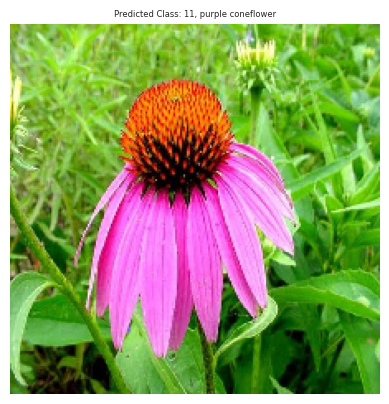

1/1 [==============================] - 0s 23ms/step


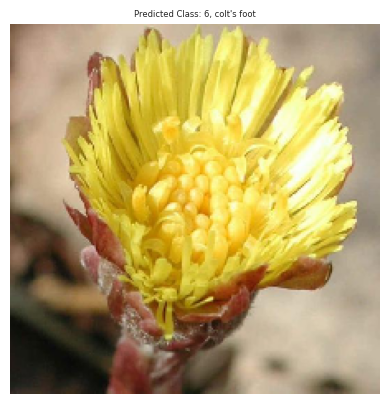

1/1 [==============================] - 0s 35ms/step


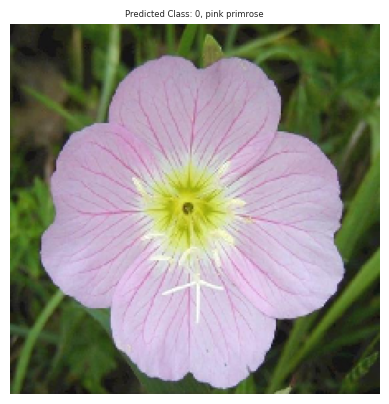

1/1 [==============================] - 0s 32ms/step


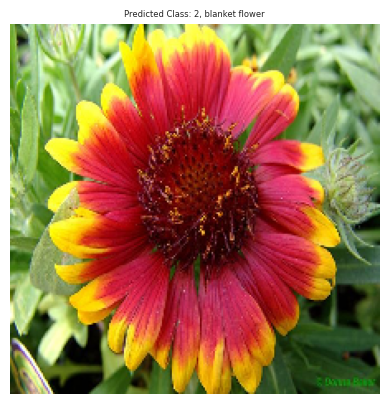

1/1 [==============================] - 0s 39ms/step


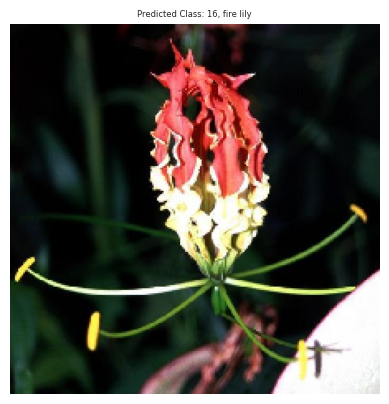

1/1 [==============================] - 0s 23ms/step


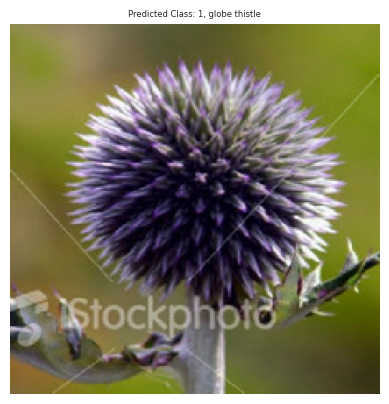

1/1 [==============================] - 0s 26ms/step


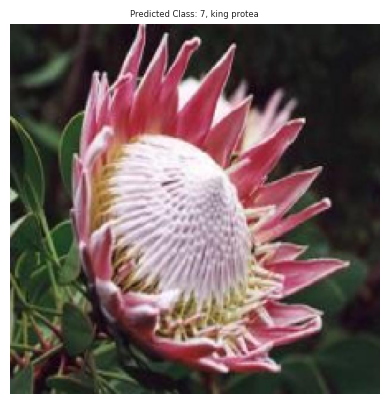

In [45]:
def predict_and_display_images(model, flowers_list, image_paths):
    for img_path in image_paths:
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        predicted_confidence = predictions[0][predicted_class_index]
        predicted_class = flowers_list[predicted_class_index]

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted Class: {predicted_class_index}, {predicted_class}")
        plt.show()


image_paths_to_test = [
    '/content/image_03835.jpg',
    '/content/image_04009.jpg',
    '/content/image_06742.jpg',
    '/content/image_07900.jpg',
    '/content/image_06781.jpg',
    '/content/image_07087.jpg',
    '/content/image_05746.jpg',

]

predict_and_display_images(model, flowers_list, image_paths_to_test)


In [30]:
 model.save('/content/mobilenet_model.h5')

Converting the saved model into a lighter version to use in the mobile application

In [46]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/mobilenet_model.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open("/content/mobilenet.tflite", "wb").write(tflite_model)

64286164

Creating a temporary user-interface to upload the image and get the predictions as output

In [43]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_flower(image_file):
    img = image.load_img(image_file, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_confidence = predictions[0][predicted_class_index]
    predicted_class = flowers_list[predicted_class_index]

    return f"Predicted Class: {predicted_class}, Confidence: {predicted_confidence:.2f}"

inter_face = gr.Interface(
    fn=predict_flower,
    inputs=gr.inputs.Image(type="filepath"),
    outputs="text",
    live=True,
    capture_session=True,
    examples=image_paths_to_test  # Pre-fill some example image paths
)

inter_face.launch()

<ipython-input-43-d6c9f6b4150d>:25: GradioDeprecationWarning: Usage of gradio.inputs is deprecated, and will not be supported in the future, please import your component from gradio.components
  inputs=gr.inputs.Image(type="filepath"),
<ipython-input-43-d6c9f6b4150d>:25: GradioDeprecationWarning: `optional` parameter is deprecated, and it has no effect
  inputs=gr.inputs.Image(type="filepath"),
<ipython-input-43-d6c9f6b4150d>:23: GradioDeprecationWarning: `capture_session` parameter is deprecated, and it has no effect
  iface = gr.Interface(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.

To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>